In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
CHECKPOINT = '../examples/comparisons/combined_boundary_DIIID/convergence_w5/alpha:0.75,weight:1e-04,lambda:1e-06,coils:3/run_01/checkpoint.json'

with open(CHECKPOINT) as f:
    ck = json.load(f)

print(f"method: {ck['method']}")
print(f"n_evals: {ck['n_evals']}")
print(f"elapsed: {ck['elapsed']:.1f}s")
print(f"best_cost: {ck['best_cost']:.4e}")
print(f"fb_failures: {ck.get('fb_failures', 'N/A')}")

method: L-BFGS
n_evals: 1236
elapsed: 68014.2s
best_cost: 3.3780e-01
fb_failures: 78


/var/folders/z5/d2ytmy3d2h18qcqwb9v71w2m0000gq/T/ipykernel_97138/2383419399.py:13: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[0].set_ylim(0, 10)
/var/folders/z5/d2ytmy3d2h18qcqwb9v71w2m0000gq/T/ipykernel_97138/2383419399.py:21: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[1].set_ylim(0, 10)
/var/folders/z5/d2ytmy3d2h18qcqwb9v71w2m0000gq/T/ipykernel_97138/2383419399.py:29: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[2].set_ylim(0, 10)


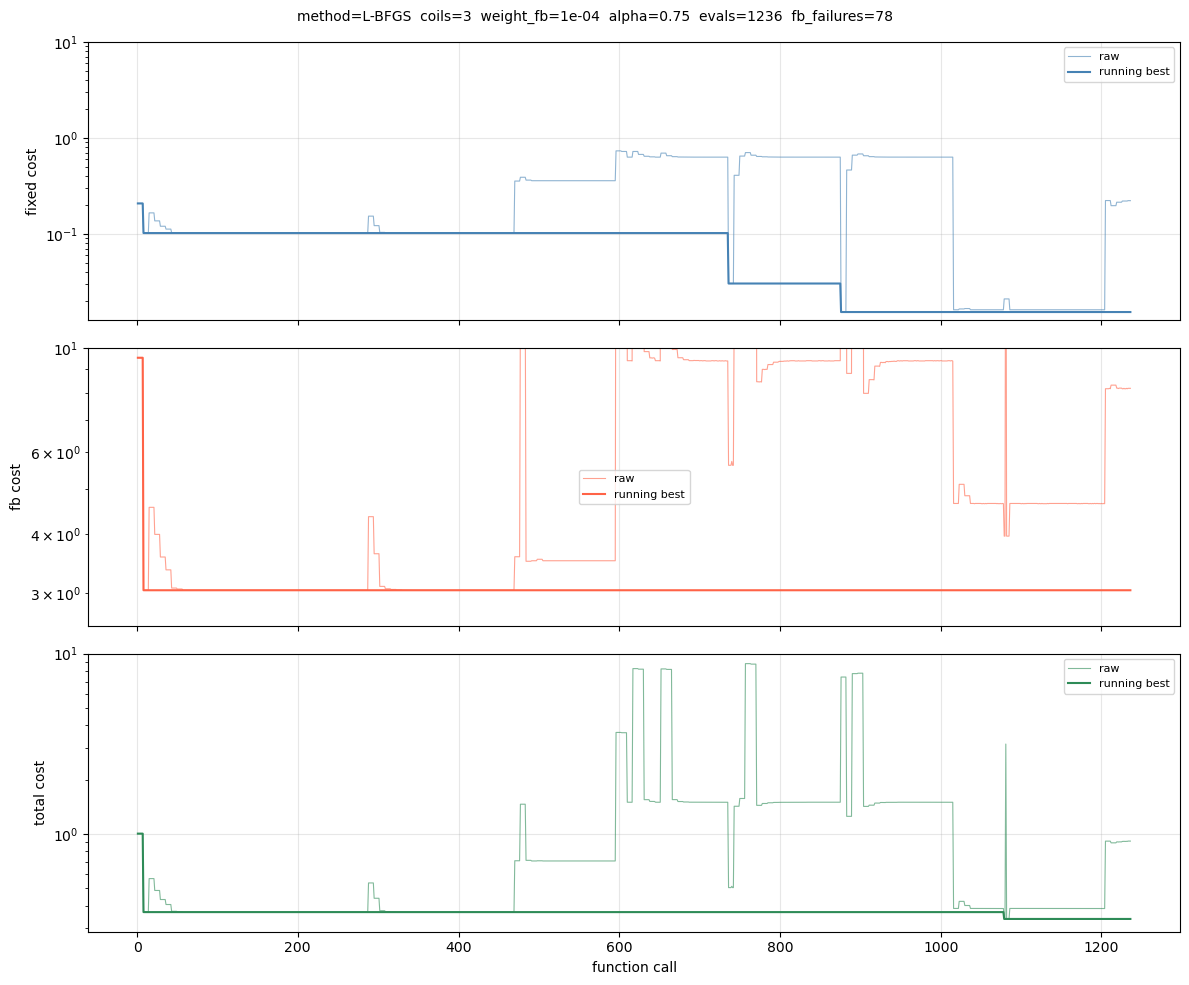

In [3]:
evals = np.arange(1, len(ck['cost_history']) + 1)
total  = np.array(ck['cost_history'], dtype=float)
fixed  = np.array([x if x is not None else np.nan for x in ck['flux_err_history']], dtype=float)
fb     = np.array([x if x is not None else np.nan for x in ck['fb_cost_history']], dtype=float)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(evals, fixed, lw=0.8, alpha=0.6, color='steelblue', label='raw')
axes[0].plot(evals, np.minimum.accumulate(np.where(np.isnan(fixed), np.inf, fixed)), lw=1.5, color='steelblue', label='running best')
axes[0].set_ylabel('fixed cost')
axes[0].set_yscale('log')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(evals, fb, lw=0.8, alpha=0.6, color='tomato', label='raw')
axes[1].plot(evals, np.minimum.accumulate(np.where(np.isnan(fb), np.inf, fb)), lw=1.5, color='tomato', label='running best')
axes[1].set_ylabel('fb cost')
axes[1].set_yscale('log')
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 10)
axes[1].grid(True, alpha=0.3)

axes[2].plot(evals, total, lw=0.8, alpha=0.6, color='seagreen', label='raw')
axes[2].plot(evals, np.minimum.accumulate(total), lw=1.5, color='seagreen', label='running best')
axes[2].set_ylabel('total cost')
axes[2].set_xlabel('function call')
axes[2].set_yscale('log')
axes[2].set_ylim(0, 10)
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

s = ck.get('optimization_settings', {})
fig.suptitle(
    f"method={ck['method']}  coils={s.get('num_coils','?')}  weight_fb={s.get('weight_fb','?'):.0e}  "
    f"alpha={s.get('alpha','?')}  evals={ck['n_evals']}  fb_failures={ck.get('fb_failures','?')}",
    fontsize=10
)
plt.tight_layout()
plt.show()